In [1]:
import itertools as it
import os
import sys
from copy import deepcopy
from glob import glob
import json

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, LinearSegmentedColormap

import joblib
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import roc_curve, roc_auc_score
from plotnine import *

from nilearn.plotting import plot_anat, plot_stat_map

sys.path.append("/home/b.y.yang/sotiraslab/BradenADLongitudinalPrediction/code")
from project_utils import *

In [2]:
wdir = "/ceph/chpc/shared/aristeidis_sotiras_group/b.y.yang_scratch/BradenADLongitudinalPrediction/3_TrainTestModel/simplified_experiments"

# Plot Haufe coefficients on the volume

We use the MUSE anatomical atlas in MNI space, then map the regional Haufe coefficients to each of their MUSE regions using `nilearn.plotting.plot_stat_map`

In [3]:
model_dict = joblib.load(os.path.join(wdir, "base/avn__svm__5yr__site.joblib"))  # load example model
feature_names = model_dict["trained_models"]["A4"]["model"].best_estimator_[:-1].get_feature_names_out()  # get feature names

# amyloid features and feature names
amyloid_idx = np.char.endswith(feature_names.astype(str), ".amyloid")
feature_names_amyloid = feature_names[amyloid_idx].astype(str)
feature_names_amyloid_raw = feature_names_amyloid
for sub in ["amyloid__", ".amyloid"]:
    feature_names_amyloid_raw = np.char.replace(feature_names_amyloid_raw, sub, "")

# volume features and feature names
volume_idx = np.char.endswith(feature_names.astype(str), ".vol")
feature_names_volume = feature_names[volume_idx].astype(str)
feature_names_volume_raw = feature_names_volume
for sub in ["volume__", ".vol"]:
    feature_names_volume_raw = np.char.replace(feature_names_volume_raw, sub, "")

# nonimg features and feature names
nonimg_idx = np.char.startswith(feature_names.astype(str), "nonimg__")
feature_names_nonimg = feature_names[nonimg_idx].astype(str)
feature_names_nonimg_raw = feature_names_nonimg
for sub in ["nonimg__"]:
    feature_names_nonimg_raw = np.char.replace(feature_names_nonimg_raw, sub, "")

/home/b.y.yang/miniconda3/envs/ad/lib/python3.12/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator ColumnTransformer from version 1.6.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
/home/b.y.yang/miniconda3/envs/ad/lib/python3.12/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator FeatureUnion from version 1.6.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
/home/b.y.yang/miniconda3/envs/ad/lib/python3.12/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator SVC from version 1.6.0 when using version 1.6.1. This might 

In [38]:
feature_names_amyloid_raw_clean = feature_names_amyloid_raw.copy()
feature_names_volume_raw_clean = feature_names_volume_raw.copy()
feature_names_amyloid_raw_clean[16:] = [" ".join(s.split()[:2]) for s in feature_names_amyloid_raw_clean[16:]]
feature_names_volume_raw_clean[22:] = [" ".join(s.split()[:2]) for s in feature_names_volume_raw_clean[22:]]

# Compute an aggregated Haufe feature importance

We average all feature importance maps across all leave-out-groups and all time-windows to derive a mean feature importance map

In [17]:
haufe_dict_site = {}
for time_window in [1,2,3,4,5]:
    model_dict = joblib.load(os.path.join(wdir, "base", f"avn__svm__{time_window}yr__site.joblib"))
    haufe_dict_site[time_window] = {s: d["haufe"] for s,d in model_dict["trained_models"].items()}

haufe_dict_tracer = {}
for time_window in [1,2,3,4,5]:
    model_dict = joblib.load(os.path.join(wdir, "base", f"avn__svm__{time_window}yr__tracer.joblib"))
    haufe_dict_tracer[time_window] = {s: d["haufe"] for s,d in model_dict["trained_models"].items()}

/home/b.y.yang/miniconda3/envs/ad/lib/python3.12/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator ColumnTransformer from version 1.6.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
/home/b.y.yang/miniconda3/envs/ad/lib/python3.12/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator FeatureUnion from version 1.6.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
/home/b.y.yang/miniconda3/envs/ad/lib/python3.12/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator SVC from version 1.6.0 when using version 1.6.1. This might 

In [18]:
r_list = []
for t, d in it.chain(haufe_dict_site.items(), haufe_dict_tracer.items()):
    for g, a in d.items():
        r = pd.Series(a.flatten(), index = feature_names)
        r["time_window"] = t
        r["leave_out_group"] = g
        r_list.append(r)
haufe_all_df = pd.concat(r_list, axis = 1).T

### Get table for excel spreadsheet

In [9]:
haufe_all_for_excel = haufe_all_df.T.copy()
new_columns = pd.MultiIndex.from_arrays([haufe_all_for_excel.loc["time_window",:], haufe_all_for_excel.loc["leave_out_group",:]])
haufe_all_for_excel.columns = new_columns
haufe_all_for_excel.drop(index = ["time_window", "leave_out_group"], inplace = True)
haufe_all_for_excel.index = haufe_all_for_excel.index.str.replace(r'\.amyloid$', '', regex=True).str.replace(r'\.vol$', '', regex=True)
haufe_all_for_excel = haufe_all_for_excel.reindex(columns = [1,2,3,4,5], level = "time_window")

In [47]:
# haufe_all_for_excel.to_excel("/home/b.y.yang/sotiraslab/BradenADLongitudinalPrediction/supplementary/haufe.xlsx")

# Plot Haufe coef using ROIs on the MNI template

In [10]:
def plot_muse_val(
    muse_val,
    muse_label,
    mni,
    mni_muse,
    label_schema
):
    
    # convert ROI labels to idx using MUSE schema dictionary
    roi_idx = list(map(label_schema["ROIs"].get, muse_label))
    
    # create ROI idx to Haufe coef mapping
    label2val = dict(zip(roi_idx, muse_val))
    
    # map ROI image using label2val
    mni_muse_data = mni_muse.get_fdata()
    muse_val_data = np.zeros_like(mni_muse_data)
    for label, value in label2val.items():
        muse_val_data[mni_muse_data == label] = value
    return nib.Nifti1Image(muse_val_data, mni_muse.affine, mni_muse.header)

muse_schema_path = "/home/b.y.yang/other_repos/pet-analysis/pet_analysis/label_schema/MUSE_label_schema.json"
with open(muse_schema_path, 'r') as fp: muse_schema = json.load(fp)

mni = nib.load("/ceph/chpc/shared/aristeidis_sotiras_group/b.y.yang_scratch/UPenn-sMRI-pipeline/sMRI/sMRI_ProcessingPipeline/Templates/RAVENS/MNI152_T1_1mm_brain_LPS_filled.nii.gz")
mni_muse = nib.load("/ceph/chpc/shared/aristeidis_sotiras_group/b.y.yang_scratch/UPenn-sMRI-pipeline/sMRI/sMRI_ProcessingPipeline/Templates/RAVENS/MNI152_T1_1mm_brain_LPS_filled_muse.nii.gz")

In [20]:
haufe_all_arr = haufe_all_df.loc[:, :"volume__Left TTG   transverse temporal gyrus.vol"].values.astype(float)

In [21]:
haufe_mean = np.mean(haufe_all_arr, axis = 0)

haufe_mean_amyloid = haufe_mean[amyloid_idx]
haufe_mean_volume = haufe_mean[volume_idx]
haufe_mean_nonimg = haufe_mean[nonimg_idx]

In [22]:
# define gradient colormap
from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm

colors = ["indigo", "dodgerblue", "white", "orange", "red"]
cmap = LinearSegmentedColormap.from_list("custom_div", colors)

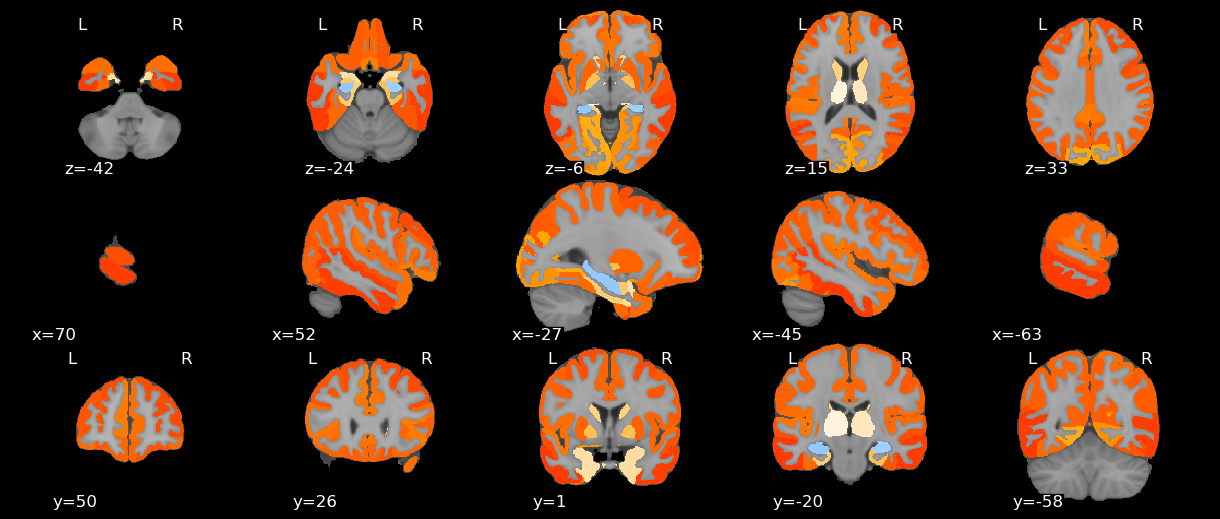

In [14]:
haufe_amyloid_img = plot_muse_val(haufe_mean_amyloid, feature_names_amyloid_raw, mni, mni_muse, muse_schema)
haufe_amyloid_plot = plot_stat_map(
    stat_map_img = haufe_amyloid_img,
    bg_img = mni,
    display_mode = "mosaic",
    cut_coords = 5,
    cmap = cmap,
    colorbar = False,
    symmetric_cbar = True,
    vmin = -0.75, vmax = 0.75,
    draw_cross = False
)

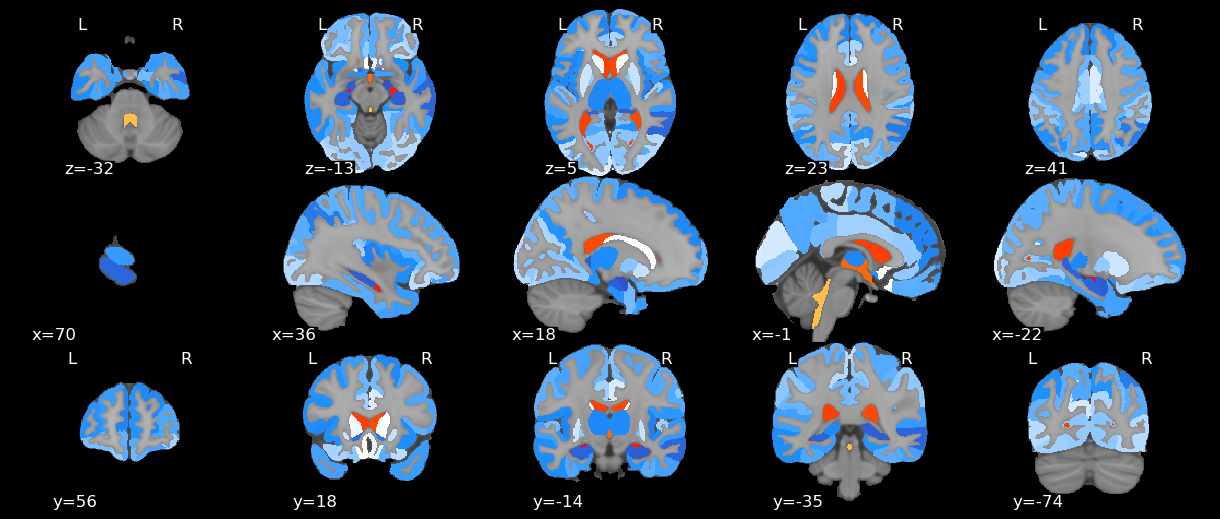

In [15]:
haufe_volume_img = plot_muse_val(haufe_mean_volume, feature_names_volume_raw, mni, mni_muse, muse_schema)
haufe_volume_plot = plot_stat_map(
    stat_map_img = haufe_volume_img,
    bg_img = mni,
    display_mode = "mosaic",
    cut_coords = 5,
    cmap = cmap,
    colorbar = False,
    symmetric_cbar = True,
    vmin = -0.75, vmax = 0.75,
    draw_cross = False
)

# Plot non-imaging features

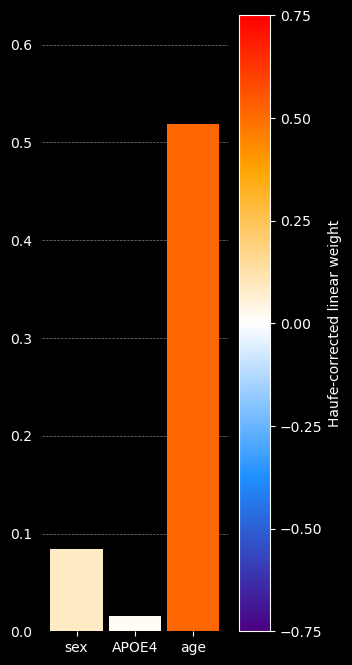

In [45]:
nonimg = haufe_mean.flatten()[:3]
feature_names_nonimg = ['sex', "APOE4", "age"]

plt.style.use('dark_background')

# norm = plt.Normalize(-0.75, 0.75)
norm = TwoSlopeNorm(vmin=-0.75, vcenter=0, vmax=0.75)
colors = cmap(norm(nonimg))

haufe_nonimg_plot, ax = plt.subplots(figsize = (3, 8))
bars_plot = ax.bar(feature_names_nonimg, nonimg, color=colors, width = 0.9)

ax.set_frame_on(False)
for y in ax.get_yticks():
    ax.axhline(y, color='gray', linewidth=0.5, linestyle='--', zorder=0)
ax.tick_params(left = False)
# ax.set_ylabel("Haufe coefficient value")

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])  # Only needed for older matplotlib
cbar = plt.colorbar(sm, ax=ax, ticks = [-0.75, -0.5, -0.25, 0, 0.25, 0.5, 0.75])
cbar.set_label('Haufe-corrected linear weight')

# Table of the top features + Haufe weights

In [39]:
feature_names_clean_dict = dict(zip(
    feature_names_volume_raw,
    feature_names_volume_raw_clean
))

In [41]:
haufe_df = pd.DataFrame([feature_names, haufe_mean.flatten()]).T
haufe_df.columns = ["feature_name", "haufe_weight"]
haufe_df["haufe_weight_abs"] = haufe_df["haufe_weight"].abs()
haufe_df["feature_type"] = haufe_df["feature_name"].str.split('__', n=1, expand=True)[0]
haufe_df["feature_name_clean"] = haufe_df["feature_name"] \
    .str.replace("amyloid__", "") \
    .str.replace("volume__", "") \
    .str.replace("nonimg__", "") \
    .str.replace(".amyloid", "") \
    .str.replace(".vol", "")
haufe_df["feature_name_cleaner"] = haufe_df["feature_name_clean"].map(feature_names_clean_dict)

In [43]:
def plot_top10(df, norm, stat = "haufe_weight", figsize = (4, 2.5), stat_x = 0.23):
    fig, ax = plt.subplots(figsize=figsize)
    ax.axis('off')  # Hide axes
    
    # get colors of each text
    # norm = TwoSlopeNorm(vmin=-0.75, vcenter=0, vmax=0.75)
    colors = cmap(norm(df[stat].astype(float).values))
    
    # Display each feature as a row of text
    for i, row in df.iterrows():
        y = 1 - i * 0.1  # vertical spacing
        circled_num = chr(9311 + i + 1)  # Unicode circled numbers: ① = U+2460 = 9312
        # text = f"{circled_num}    "
        ax.text(0.05, y, circled_num, fontsize=14, va='center', ha='left', color = "gray")  # [1][2][5]  # circled number
        ax.text(stat_x, y, f"{row[stat]:.3f}", color = colors[i, :], va='center', ha='right')
        ax.text(0.95,  y, f"{row['feature_name_cleaner']}", color = "white", va='center', ha='right', wrap = True)
    
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    plt.tight_layout()
    plt.show()

    return fig, ax

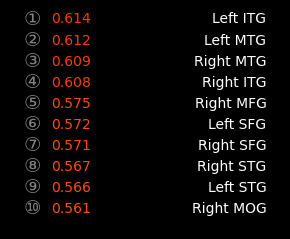

In [53]:
haufe_top10_amyloid = haufe_df[haufe_df["feature_type"] == "amyloid"].sort_values(by = "haufe_weight_abs", ascending = False).iloc[:10, :].reset_index(drop=True)
fig_top10_amyloid, ax_top10_amyloid = plot_top10(haufe_top10_amyloid, norm, figsize = (3,2.5), stat_x = 0.3)

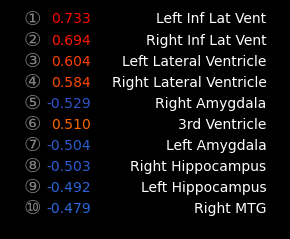

In [54]:
haufe_top10_volume = haufe_df[haufe_df["feature_type"] == "volume"].sort_values(by = "haufe_weight_abs", ascending = False).iloc[:10, :].reset_index(drop=True)
fig_top10_volume, ax_top10_volume = plot_top10(haufe_top10_volume, norm, figsize = (3,2.5), stat_x = 0.3)

# Save figures

In [ ]:
odir = "/home/b.y.yang/sotiraslab/BradenADLongitudinalPrediction/figures/haufe"

haufe_amyloid_plot.savefig(os.path.join(odir, "haufe_amyloid.png"), dpi = 300)
haufe_volume_plot.savefig(os.path.join(odir, "haufe_volume.png"), dpi = 300)
haufe_nonimg_plot.savefig(os.path.join(odir, "haufe_nonimg.png"), dpi = 300, bbox_inches = "tight")
fig_top10_amyloid.savefig(os.path.join(odir, "top10_amyloid.png"), dpi = 300)
fig_top10_volume.savefig(os.path.join(odir, "top10_volume.png"), dpi = 300)

# Plot the change in Haufe weight vs. time window, using linear regression

In [22]:
haufe_slope_df = pd.read_csv("/home/b.y.yang/sotiraslab/BradenADLongitudinalPrediction/code/4_FeatureImportance/haufe_slope.csv")

In [23]:
haufe_mean_slope_df = haufe_slope_df \
    .groupby("feature_name")["slope"] \
    .mean() \
    .reset_index()
haufe_mean_slope_metadata = haufe_mean_slope_df["feature_name"] \
    .str.split("__", expand = True) \
    .rename(columns = {0: "feature_type", 1: "feature_name_raw"})
haufe_mean_slope_df = pd.concat([haufe_mean_slope_df, haufe_mean_slope_metadata], axis = 1)
haufe_mean_slope_df["feature_name_raw"] = haufe_mean_slope_df["feature_name_raw"].str.split(".", expand = True)[0]

In [24]:
haufe_slope_amyloid_df = haufe_mean_slope_df[haufe_mean_slope_df["feature_type"] == "amyloid"]
haufe_slope_amyloid, haufe_slope_amyloid_feature_names = haufe_slope_amyloid_df["slope"].values, haufe_slope_amyloid_df["feature_name_raw"].values

haufe_slope_volume_df = haufe_mean_slope_df[haufe_mean_slope_df["feature_type"] == "volume"]
haufe_slope_volume, haufe_slope_volume_feature_names = haufe_slope_volume_df["slope"].values, haufe_slope_volume_df["feature_name_raw"].values

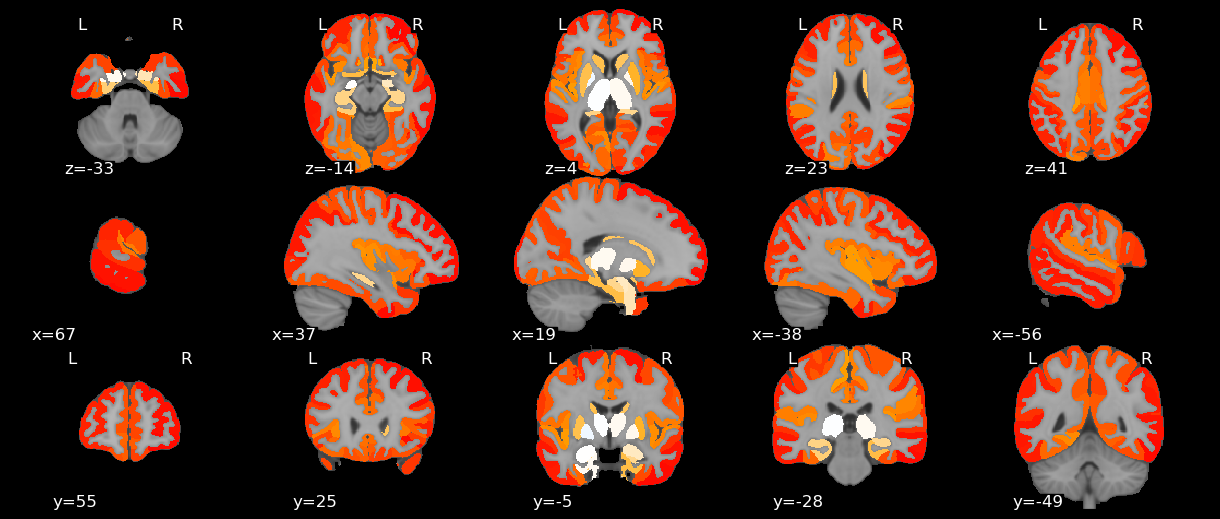

In [25]:
haufe_slope_amyloid_img = plot_muse_val(haufe_slope_amyloid, haufe_slope_amyloid_feature_names, mni, mni_muse, muse_schema)
haufe_slope_amyloid_plot = plot_stat_map(
    stat_map_img = haufe_slope_amyloid_img,
    bg_img = mni,
    display_mode = "mosaic",
    cut_coords = 5,
    cmap = cmap,
    colorbar = False,
    symmetric_cbar = True,
    vmin = -0.1, vmax = 0.1,
    draw_cross = False
)

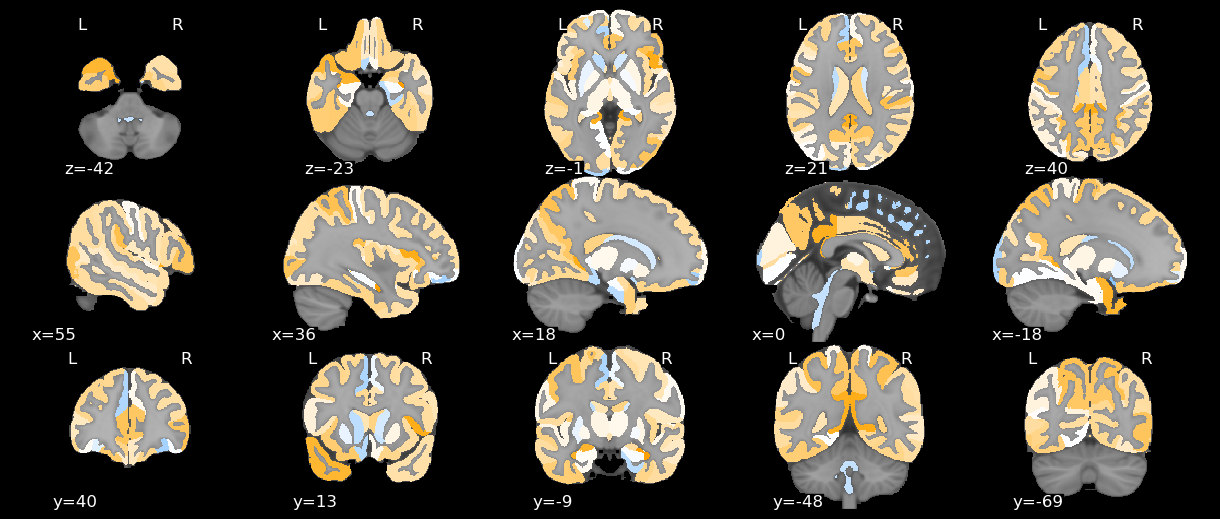

In [28]:
haufe_slope_volume_img = plot_muse_val(haufe_slope_volume, haufe_slope_volume_feature_names, mni, mni_muse, muse_schema)
haufe_slope_volume_plot = plot_stat_map(
    stat_map_img = haufe_slope_volume_img,
    bg_img = mni,
    display_mode = "mosaic",
    cut_coords = 5,
    cmap = cmap,
    colorbar = False,
    symmetric_cbar = True,
    vmin = -0.1, vmax = 0.1,
    draw_cross = False
)

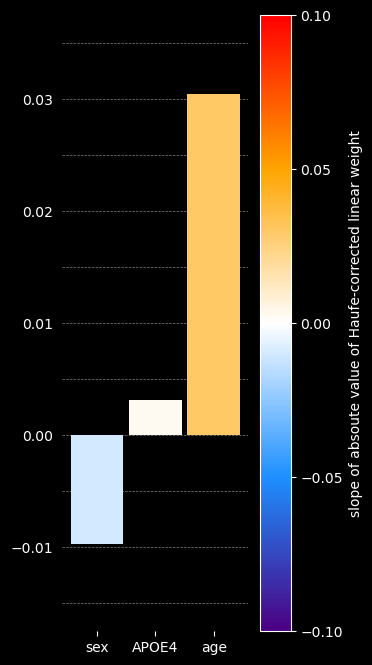

In [29]:
haufe_slope_nonimg_df = haufe_mean_slope_df[haufe_mean_slope_df["feature_type"] == "nonimg"]
# nonimg_slope = haufe_slope.flatten()[:3]
# feature_names_nonimg = ['sex', "APOE-e4", "age"]
nonimg_slope = haufe_slope_nonimg_df["slope"].values[[2,1,0]]
feature_names_nonimg = ["sex", "APOE4", "age"]

plt.style.use('dark_background')
# plt.rc('font', family='Arial', weight='bold', size=14)

# Normalize the values to [0, 1] for the colormap
norm = TwoSlopeNorm(vmin=-0.1, vcenter=0, vmax=0.1)
colors = cmap(norm(nonimg_slope))  # You can use any matplotlib colormap

# Create the bar plot with mapped colors
haufe_slope_nonimg_plot, ax = plt.subplots(figsize = (3, 8))
bars_plot = ax.bar(feature_names_nonimg, nonimg_slope, color=colors, width = 0.9)

ax.set_frame_on(False)
for y in ax.get_yticks():
    ax.axhline(y, color='gray', linewidth=0.5, linestyle='--', zorder=0)
ax.tick_params(left = False)
# ax.set_ylabel("Haufe coefficient value")

# Add a colorbar
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])  # Only needed for older matplotlib
cbar = plt.colorbar(sm, ax=ax, ticks = [-0.1, -0.05, 0, 0.05, 0.10])
cbar.set_label('slope of absoute value of Haufe-corrected linear weight')

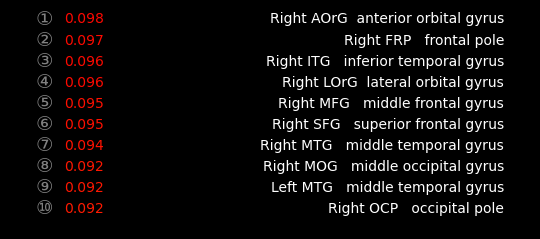

In [32]:
# haufe_slope_top10_amyloid = haufe_df[haufe_df["feature_type"] == "amyloid"].sort_values(by = "slope_abs", ascending = False).iloc[:10, :].reset_index(drop=True)
haufe_slope_top10_amyloid = haufe_slope_amyloid_df.sort_values(by = "slope", ascending = False).iloc[:10, :].reset_index(drop=True).rename(columns={"feature_name_raw": "feature_name_clean"})
fig_top10_slope_amyloid, ax_top10_slope_amyloid = plot_top10(haufe_slope_top10_amyloid, norm, stat = "slope", figsize = (5.5,2.5), stat_x = 0.18)

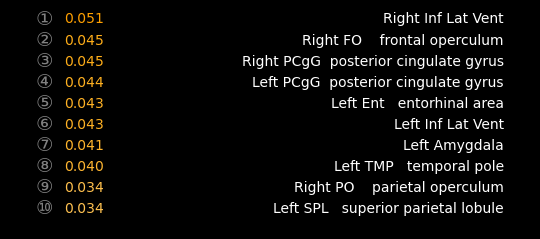

In [33]:
# haufe_slope_top10_volume = haufe_df[haufe_df["feature_type"] == "volume"].sort_values(by = "slope_abs", ascending = False).iloc[:10, :].reset_index(drop=True)
haufe_slope_top10_volume = haufe_slope_volume_df.sort_values(by = "slope", ascending = False).iloc[:10, :].reset_index(drop=True).rename(columns={"feature_name_raw": "feature_name_clean"})
fig_top10_slope_volume, ax_top10_slope_volume = plot_top10(haufe_slope_top10_volume, norm, stat = "slope", figsize = (5.5,2.5), stat_x = 0.18)

In [ ]:
odir = "/home/b.y.yang/sotiraslab/BradenADLongitudinalPrediction/figures/haufe"

haufe_slope_amyloid_plot.savefig(os.path.join(odir, "haufe_amyloid_slope.png"), dpi = 300)
haufe_slope_volume_plot.savefig(os.path.join(odir, "haufe_volume_slope.png"), dpi = 300)
haufe_slope_nonimg_plot.savefig(os.path.join(odir, "haufe_nonimg_slope.png"), dpi = 300, bbox_inches = "tight")
fig_top10_slope_amyloid.savefig(os.path.join(odir, "top10_amyloid_slope.png"), dpi = 300)
fig_top10_slope_volume.savefig(os.path.join(odir, "top10_volume_slope.png"), dpi = 300)